In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"

PRED_FILES = [
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m7g.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1y.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.Inosine.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.f5c.tsv",
]

PROB_TH = 0.95
MIN_DEPTH = 10
SITE_POS_FRAC = 0.35

POS_COL = 1
KMER_COL = 2
PROB_COL = 5

POS_IS_1BASED = True
K = 5

NBINS_PER_SEG = 200
SMOOTH_SIGMA = 2.0


In [2]:
from collections import defaultdict

def _get_attr(attr_str: str, key: str):
    token = key + ' "'
    i = attr_str.find(token)
    if i == -1:
        return None
    j = attr_str.find('";', i + len(token))
    if j == -1:
        return None
    return attr_str[i + len(token): j]

def build_tx_models_utr_cds(gtf_path: str):
    """
    返回 tx_models: dict[tx_nov] = dict(
        strand, tx_len,
        utr5_len, cds_t_start, cds_t_end, cds_len, utr3_len
    )
    仅对protein_coding且有CDS的转录本可用（否则不返回）。
    """
    exons = defaultdict(list)   # tx -> list[(start,end)]
    cdss  = defaultdict(list)   # tx -> list[(start,end)]
    strand_map = {}
    bio_map = {}

    with open(gtf_path, "r") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            feature = parts[2]
            start = int(parts[3])
            end   = int(parts[4])
            strand = parts[6]
            attrs = parts[8]

            if feature == "transcript":
                tx = _get_attr(attrs, "transcript_id")
                if tx is None:
                    continue
                tx_nov = tx.split(".")[0]
                strand_map[tx_nov] = strand
                bio = _get_attr(attrs, "transcript_biotype")
                if bio is None:
                    bio = _get_attr(attrs, "gene_biotype")
                bio_map[tx_nov] = bio
            elif feature == "exon":
                tx = _get_attr(attrs, "transcript_id")
                if tx is None:
                    continue
                tx_nov = tx.split(".")[0]
                exons[tx_nov].append((start, end))
                strand_map.setdefault(tx_nov, strand)
            elif feature == "CDS":
                tx = _get_attr(attrs, "transcript_id")
                if tx is None:
                    continue
                tx_nov = tx.split(".")[0]
                cdss[tx_nov].append((start, end))
                strand_map.setdefault(tx_nov, strand)

    tx_models = {}

    for tx, exon_list in exons.items():
        if bio_map.get(tx) != "protein_coding":
            continue
        if tx not in cdss or len(cdss[tx]) == 0:
            continue

        strand = strand_map.get(tx, "+")
        if strand == "+":
            exon_list_sorted = sorted(exon_list, key=lambda x: x[0])
        else:
            exon_list_sorted = sorted(exon_list, key=lambda x: x[0], reverse=True)

        exon_t0 = []  # list[(g_start,g_end,t_start,t_end)]
        tcur = 1
        for (gs, ge) in exon_list_sorted:
            L = ge - gs + 1
            t_start = tcur
            t_end = tcur + L - 1
            exon_t0.append((gs, ge, t_start, t_end))
            tcur = t_end + 1
        tx_len = tcur - 1

        cds_t_min = None
        cds_t_max = None

        for (cs, ce) in cdss[tx]:
            for (gs, ge, t_start, t_end) in exon_t0:
                ov_s = max(cs, gs)
                ov_e = min(ce, ge)
                if ov_s > ov_e:
                    continue
                if strand == "+":
                    off0 = ov_s - gs
                    off1 = ov_e - gs
                    tt0 = t_start + off0
                    tt1 = t_start + off1
                else:
                    off0 = ge - ov_e
                    off1 = ge - ov_s
                    tt0 = t_start + off0
                    tt1 = t_start + off1

                if cds_t_min is None or tt0 < cds_t_min:
                    cds_t_min = tt0
                if cds_t_max is None or tt1 > cds_t_max:
                    cds_t_max = tt1

        if cds_t_min is None or cds_t_max is None or cds_t_max < cds_t_min:
            continue

        utr5_len = cds_t_min - 1
        cds_len  = cds_t_max - cds_t_min + 1
        utr3_len = tx_len - cds_t_max
        if utr5_len < 0 or utr3_len < 0 or cds_len <= 0:
            continue

        tx_models[tx] = dict(
            strand=strand,
            tx_len=tx_len,
            utr5_len=utr5_len,
            cds_t_start=cds_t_min,
            cds_t_end=cds_t_max,
            cds_len=cds_len,
            utr3_len=utr3_len
        )

    return tx_models

tx_models = build_tx_models_utr_cds(GTF)
print("protein_coding transcripts with CDS:", len(tx_models))


protein_coding transcripts with CDS: 80901


In [3]:
def collect_positive_sites(WT: str,
                           PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5,
                           pos_col=1, prob_col=5, kmer_col=2, K=5):
    """
    沿用你现有逻辑：sid=transcript|pos|kmer 聚合，返回阳性位点列表：
      [(tx_nov, pos_int), ...]
    """
    site_dict = {}  # sid -> [n_hi, n_all]
    with open(WT, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) <= max(pos_col, prob_col, kmer_col):
                continue

            tid_raw = parts[0]
            pos_str = parts[pos_col]
            kmer = parts[kmer_col].upper()
            if len(kmer) != K:
                continue

            try:
                pos = int(pos_str)
            except ValueError:
                continue
            if not POS_IS_1BASED:
                pos += 1

            try:
                prob = float(parts[prob_col])
            except ValueError:
                continue

            sid = "|".join([tid_raw, str(pos), kmer])
            if sid not in site_dict:
                site_dict[sid] = [0, 0]
            if prob > PROB_TH:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    pos_sites = []
    for sid, (n_hi, n_all) in site_dict.items():
        if n_all < MIN_DEPTH:
            continue
        if (n_hi / n_all) < SITE_POS_FRAC:
            continue
        tid_raw, pos_str, _ = sid.split("|")
        tx_nov = tid_raw.split(".")[0]
        pos_sites.append((tx_nov, int(pos_str)))

    return pos_sites

def sites_to_metagene_positions(pos_sites, tx_models):
    """
    将 (tx,pos) 映射为 metagene x in [0,3]
    仅保留能在tx_models中找到且 pos 落在(utr/cds/utr)范围内的点。
    """
    xs = []
    skipped = 0
    for tx, pos in pos_sites:
        m = tx_models.get(tx)
        if m is None:
            skipped += 1
            continue

        utr5 = m["utr5_len"]
        cds_s = m["cds_t_start"]
        cds_e = m["cds_t_end"]
        cdsL = m["cds_len"]
        utr3 = m["utr3_len"]

        if pos < 1 or pos > m["tx_len"]:
            skipped += 1
            continue

        if pos <= utr5:
            if utr5 <= 0:
                skipped += 1
                continue
            x = (pos - 1) / utr5  # 0..(1-eps)
            xs.append(x)
        elif cds_s <= pos <= cds_e:
            x = 1.0 + (pos - cds_s) / cdsL  # 1..(2-eps)
            xs.append(x)
        else:
            if utr3 <= 0:
                skipped += 1
                continue
            x = 2.0 + (pos - cds_e - 1) / utr3  # 2..(3-eps)
            xs.append(x)

    return np.asarray(xs, dtype=float), skipped


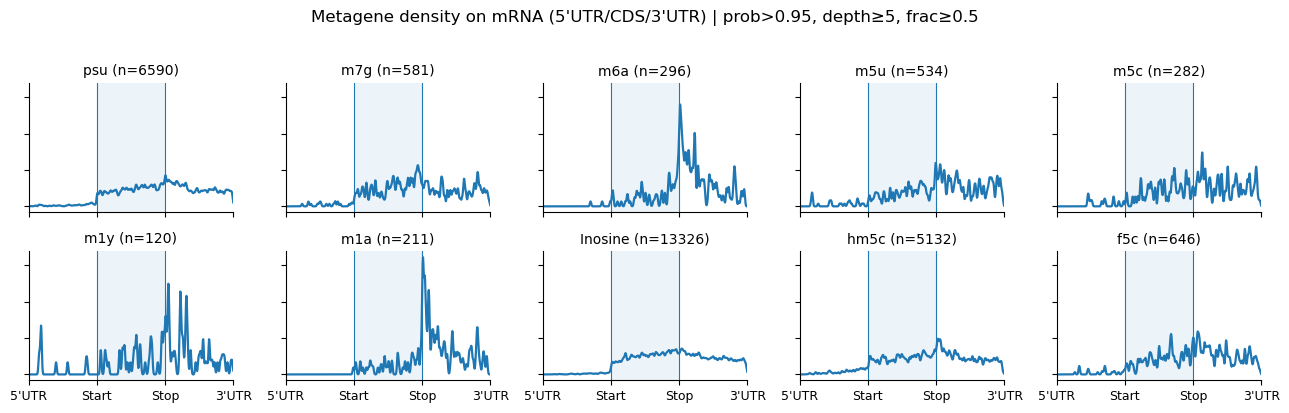

In [ ]:
def gaussian_smooth(y, sigma=2.0):
    if sigma <= 0:
        return y
    r = int(max(1, round(3*sigma)))
    x = np.arange(-r, r+1)
    k = np.exp(-(x*x)/(2*sigma*sigma))
    k /= k.sum()
    return np.convolve(y, k, mode="same")

def density_curve(xs, nbins_per_seg=200, smooth_sigma=2.0):
    """
    xs in [0,3]. 统一在[0,3]上做直方图，然后平滑，最后归一化为密度（面积~1）。
    """
    nbins = nbins_per_seg * 3
    hist, edges = np.histogram(xs, bins=nbins, range=(0,3), density=False)
    hist = hist.astype(float)
    y = gaussian_smooth(hist, sigma=smooth_sigma)
    dx = (edges[1] - edges[0])
    area = y.sum() * dx
    if area > 0:
        y = y / area
    xmid = (edges[:-1] + edges[1:]) / 2
    return xmid, y

def mod_name_from_path(p: str) -> str:
    fn = os.path.basename(p)
    return fn.replace("rep1.", "").replace(".tsv", "")

def plot_metagene_density_grid(files, tx_models,
                               PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5,
                               nbins_per_seg=200, smooth_sigma=2.0,
                               ncols=5):
    n = len(files)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.6, nrows*2.0), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for i, fp in enumerate(files):
        ax = axes[i]
        mod = mod_name_from_path(fp)

        pos_sites = collect_positive_sites(fp, PROB_TH, MIN_DEPTH, SITE_POS_FRAC,
                                           pos_col=POS_COL, prob_col=PROB_COL, kmer_col=KMER_COL, K=K)
        xs, skipped = sites_to_metagene_positions(pos_sites, tx_models)

        if xs.size == 0:
            ax.text(0.5, 0.5, f"{mod}\nno sites", ha="center", va="center", transform=ax.transAxes, fontsize=9)
            ax.set_title(mod, fontsize=10)
            ax.set_xlim(0, 3)
            continue

        xmid, y = density_curve(xs, nbins_per_seg=nbins_per_seg, smooth_sigma=smooth_sigma)
        ax.plot(xmid, y, lw=1.6)

        ax.axvline(1.0, lw=0.8)
        ax.axvline(2.0, lw=0.8)
        ax.axvspan(1.0, 2.0, alpha=0.08)

        ax.set_title(f"{mod} (n={xs.size})", fontsize=10)
        ax.set_xlim(0, 3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    for ax in axes[:n]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[: (nrows-1)*ncols]:
        ax.set_xticklabels([])

    for ax in axes[(nrows-1)*ncols : nrows*ncols]:
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(["5'UTR", "Start", "Stop", "3'UTR"], fontsize=9)

    for r in range(nrows):
        for c in range(ncols):
            idx = r*ncols + c
            if idx >= n:
                continue
            if c != 0:
                axes[idx].set_yticklabels([])

    fig.suptitle(f"Metagene density on mRNA (5'UTR/CDS/3'UTR) | prob>{PROB_TH}, depth≥{MIN_DEPTH}, frac≥{SITE_POS_FRAC}",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    
    plt.show()


plot_metagene_density_grid(PRED_FILES, tx_models,
                           PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
                           nbins_per_seg=NBINS_PER_SEG, smooth_sigma=5,
                           ncols=5)



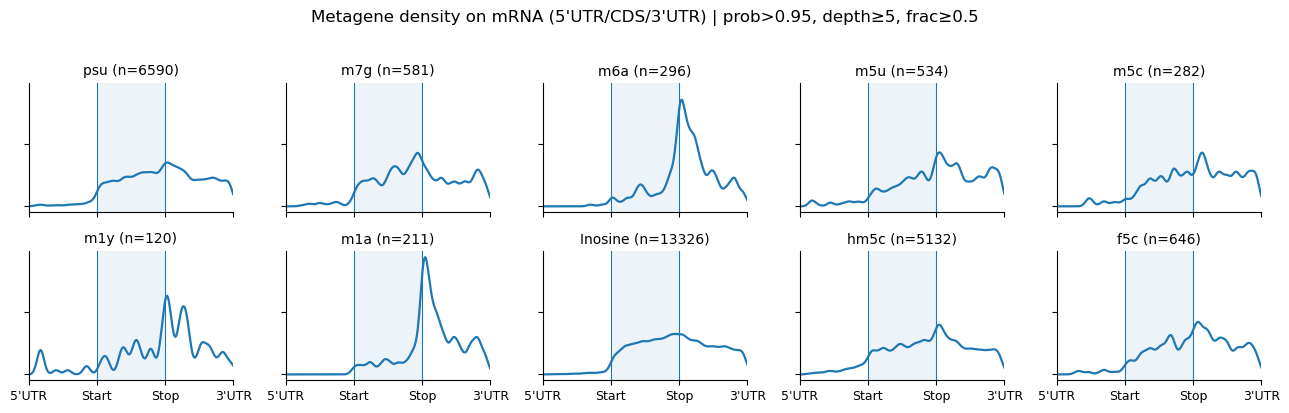

In [ ]:
plot_metagene_density_grid(PRED_FILES, tx_models,
                           PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
                           nbins_per_seg=NBINS_PER_SEG, smooth_sigma=10,
                           ncols=5)

In [8]:

def precompute_metagene_curves(files, tx_models,
                               PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5,
                               nbins_per_seg=200, smooth_sigma=2.0):
    curves = {}  # mod -> dict(xmid, y, n, skipped)
    for fp in files:
        mod = mod_name_from_path(fp)

        pos_sites = collect_positive_sites(fp, PROB_TH, MIN_DEPTH, SITE_POS_FRAC,
                                           pos_col=POS_COL, prob_col=PROB_COL, kmer_col=KMER_COL, K=K)
        xs, skipped = sites_to_metagene_positions(pos_sites, tx_models)
        if xs.size == 0:
            curves[mod] = dict(xmid=None, y=None, n=0, skipped=skipped)
            continue

        xmid, y = density_curve(xs, nbins_per_seg=nbins_per_seg, smooth_sigma=smooth_sigma)
        curves[mod] = dict(xmid=xmid, y=y, n=int(xs.size), skipped=int(skipped))
    return curves

curves = precompute_metagene_curves(
    PRED_FILES, tx_models,
    PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
    nbins_per_seg=NBINS_PER_SEG, smooth_sigma=10
)

{k: v["n"] for k, v in curves.items()}


{'psu': 6590,
 'm7g': 581,
 'm6a': 296,
 'm5u': 534,
 'm5c': 282,
 'm1y': 120,
 'm1a': 211,
 'Inosine': 13326,
 'hm5c': 5132,
 'f5c': 646}

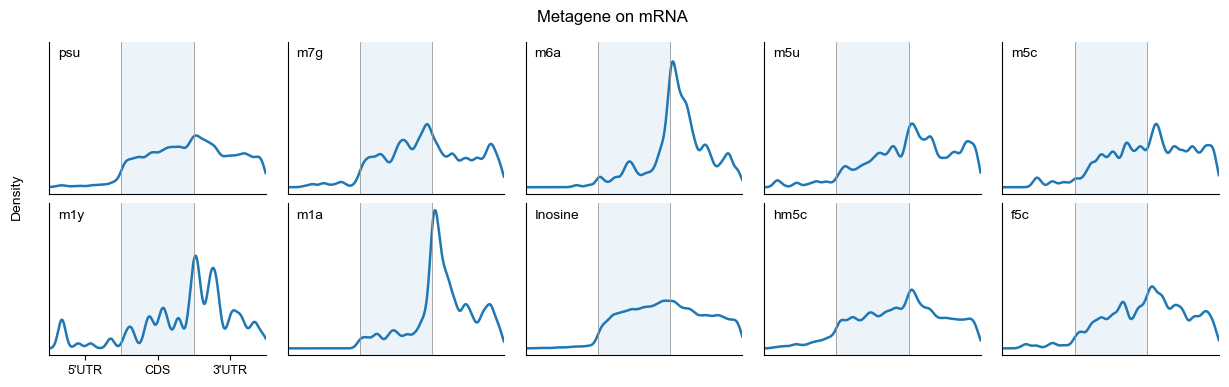

In [29]:
def plot_metagene_density_grid_from_curves(curves,
                                           ncols=5,
                                           figsize_per_ax=(2.45, 1.8),
                                           lw=1.6,
                                           title_font=10,
                                           suptitle_font=12,
                                           shade_cds=True,
                                           show_boundaries=True,
                                           sharey=True,
                                           wspace=0.15,
                                           hspace=0.20):
    mods = list(curves.keys())
    n = len(mods)
    nrows = int(np.ceil(n / ncols))
    WINDOW = 100
    import matplotlib as mpl

    mpl.rcParams["font.family"] = "Arial"
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"]  = 42
    fig_w = ncols * figsize_per_ax[0]
    fig_h = nrows * figsize_per_ax[1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True, sharey=sharey)
    axes = np.array(axes).reshape(-1)

    for i, mod in enumerate(mods):
        ax = axes[i]
        d = curves[mod]

        if d["n"] == 0 or d["xmid"] is None:
            ax.text(0.04, 0.96, mod, transform=ax.transAxes,
                    ha="left", va="top", fontsize=title_font)
            ax.text(0.5, 0.5, "no sites", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9)
            ax.set_xlim(0, 3)
            continue

        ax.plot(d["xmid"], d["y"], lw=lw)

        if show_boundaries:
            ax.axvline(1.0, lw=0.6, color="0.6")
            ax.axvline(2.0, lw=0.6, color="0.6")

        if shade_cds:
            ax.axvspan(1.0, 2.0, alpha=0.08)

        ax.text(0.04, 0.96, mod, transform=ax.transAxes,
                ha="left", va="top", fontsize=title_font,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2))


        ax.set_xlim(0, 3)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    for ax in axes[:n]:
        ax.set_xticklabels([])

    for ax in axes[:n]:
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        ax.set_yticks([])


    left_bottom_idx = (nrows - 1) * ncols + 0
    if left_bottom_idx < n:
        axes[left_bottom_idx].tick_params(axis="x", which="both", bottom=True, labelbottom=True)
        axes[left_bottom_idx].set_xticks([0.5, 1.5, 2.5])
        axes[left_bottom_idx].set_xticklabels(["5'UTR", "CDS", "3'UTR"], fontsize=9)

    for r in range(nrows):
        for c in range(ncols):
            idx = r*ncols + c
            if idx >= n:
                continue
            if c != 0:
                axes[idx].set_yticklabels([])

    fig.suptitle("Metagene on mRNA", y=1.02, fontsize=suptitle_font)
    fig.text(0.008, 0.5, "Density", rotation=90, va="center", ha="left", fontsize=10)

    fig.subplots_adjust(left=0.04, right=0.995, bottom=0.06, top=0.93,
                    wspace=0.10, hspace=0.06)
    plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig21_metagene.pdf",dpi=1200,format="pdf",bbox_inches="tight")
    plt.show()
plot_metagene_density_grid_from_curves(curves, ncols=5, lw=1.8, shade_cds=True, show_boundaries=True)


In [25]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "/mnt/sunxh/sunxh/wattmamba/new_result"
os.makedirs(OUTDIR, exist_ok=True)

PREFIX = "supfig21"

# =========================
# =========================

rows = []
meta = []
for mod, d in curves.items():
    n = int(d.get("n", 0) or 0)
    skipped = int(d.get("skipped", 0) or 0)
    xmid = d.get("xmid", None)
    y = d.get("y", None)

    meta.append(dict(mod=mod, n_sites=n, skipped=skipped))

    if xmid is None or y is None or n == 0:
        continue

    xmid = np.asarray(xmid, dtype=float)
    y = np.asarray(y, dtype=float)
    for xi, yi in zip(xmid, y):
        rows.append(dict(mod=mod, x=xi, density=yi, n_sites=n, skipped=skipped))

df_curves = pd.DataFrame(rows)
df_meta   = pd.DataFrame(meta)

csv_curves = os.path.join(OUTDIR, f"{PREFIX}_metagene_curves.csv")
csv_meta   = os.path.join(OUTDIR, f"{PREFIX}_metagene_meta.csv")
df_curves.to_csv(csv_curves, index=False)
df_meta.to_csv(csv_meta, index=False)

params = dict(
    gtf=GTF,
    pred_files=PRED_FILES,
    PROB_TH=PROB_TH,
    MIN_DEPTH=MIN_DEPTH,
    SITE_POS_FRAC=SITE_POS_FRAC,
    nbins_per_seg=NBINS_PER_SEG,
    smooth_sigma=10,
    POS_IS_1BASED=POS_IS_1BASED,
    POS_COL=POS_COL,
    KMER_COL=KMER_COL,
    PROB_COL=PROB_COL,
)
json_params = os.path.join(OUTDIR, f"{PREFIX}_metagene_params.json")
with open(json_params, "w") as f:
    json.dump(params, f, indent=2)

print("Saved:")
print(" ", csv_curves)
print(" ", csv_meta)
print(" ", json_params)

Saved:
  /mnt/sunxh/sunxh/wattmamba/new_result/supfig21_metagene_curves.csv
  /mnt/sunxh/sunxh/wattmamba/new_result/supfig21_metagene_meta.csv
  /mnt/sunxh/sunxh/wattmamba/new_result/supfig21_metagene_params.json
